In [ ]:
# ROM Notebook for UTB
# Cell 1 — Notebook title and methodological note
# Corrected ROM notebook for UTB benchmark revision

# This notebook implements the corrected reduced-order model workflow for the UTB benchmark manuscript.

## Main workflow

# 1. Load UTB thermal response data and hourly load data.
# 2. Inspect and clean the raw UTB time axis.
# 3. Collapse duplicate UTB timestamps.
# 4. Interpolate thermal observables onto the hourly load grid.
# 5. Split data into calibration and holdout periods.
# 6. Perform spectral and autocorrelation diagnostics.
# 7. Calibrate:
#    - one-state ROM,
#   - exact cascade two-state ROM,
#   - optional physically coupled two-state ROM.
# 8. Evaluate calibration and holdout performance.
# 9. Generate manuscript-ready parameter and performance tables.
# 10. Save corrected figures, tables, and results.

## Important corrections relative to the earlier notebook

# - The cascade two-state ROM is integrated using the exact analytical hourly update.
# - The bootstrap confidence interval function compares bootstrapped pseudo-data with fixed predictions, not original data with pseudo-data.
# - Table outputs are generated directly from computed metrics to avoid manuscript/table desynchronization.
# - The physically coupled model is included as an optional alternative structure.


In [ ]:
# Cell 2 — Imports and global settings
from google.colab import drive
drive.mount("/content/drive")

import os
import math
import pickle
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
from scipy.signal import welch

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10

print("Imports completed.")


Mounted at /content/drive
Imports completed.


In [ ]:
# Cell 3 — User paths and settings
# =========================
# USER PATHS
# =========================

FOLDER = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "UTB_CommunityGeothermal/Data_submission/"
    "ppt_page11-13_5yr_Orlando"
)

UTB_RESPONSE_PATH = os.path.join(FOLDER, "T_UTB 5_annotated.dat")
LOAD_PATH = os.path.join(FOLDER, "UTB_prop_dim.dat")

OUT_DIR = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "UTB_CommunityGeothermal/revision_results_corrected"
)

os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# DATA SETTINGS
# =========================

# Use this variable consistently. Do not hardcode another skiprows value later.
LOAD_SKIPROWS = 12

CALIB_YEARS = 3.0
HOURS_PER_YEAR = 365.25 * 24.0
SECONDS_PER_YEAR = 365.25 * 24.0 * 3600.0
DT_H = 3600.0  # hourly time step in seconds

# =========================
# OPTIMIZATION SETTINGS
# =========================

N_SEEDS_BASE = 10
MAXITER_BASE = 1000
POPSIZE_BASE = 20
DE_TOL = 1e-7

# Optional lighter sensitivity settings
N_SEEDS_SENS = 5
MAXITER_SENS = 500
POPSIZE_SENS = 15

# =========================
# BOOTSTRAP SETTINGS
# =========================

N_BOOT = 500
RNG_BOOT = 1234

# =========================
# DIAGNOSTIC SETTINGS
# =========================

WELCH_NPERSEG = 4096
ACF_MAX_LAG_H = 24 * 365  # one year of hourly lags

print("FOLDER exists:", os.path.exists(FOLDER))
print("UTB_RESPONSE_PATH exists:", os.path.exists(UTB_RESPONSE_PATH))
print("LOAD_PATH exists:", os.path.exists(LOAD_PATH))
print("OUT_DIR:", OUT_DIR)


FOLDER exists: True
UTB_RESPONSE_PATH exists: True
LOAD_PATH exists: True
OUT_DIR: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected


In [ ]:
# Cell 4 — File readers and column normalization
def load_table_auto(path: str, skiprows: int = 0) -> pd.DataFrame:
    """
    Load a delimited table with lightweight auto-detection.

    Supports:
    - CSV files,
    - whitespace-delimited TXT/DAT files,
    - automatically inferred separators.
    """
    ext = os.path.splitext(path)[1].lower()

    if ext == ".csv":
        return pd.read_csv(path, skiprows=skiprows)

    try:
        return pd.read_csv(path, sep=r"\s+", skiprows=skiprows, engine="python")
    except Exception:
        return pd.read_csv(path, sep=None, skiprows=skiprows, engine="python")


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize common column names.
    """
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    # Specific UTB file convention
    if "TLocal" in out.columns and "time_s" not in out.columns:
        out = out.rename(columns={"TLocal": "time_s"})

    rename_map = {}

    for c in out.columns:
        cl = c.lower().strip()

        if cl in ["time", "times", "tlocal", "time_sec", "time_s"] and "time_s" not in out.columns:
            rename_map[c] = "time_s"

        if cl in ["load", "qload", "utb_load"] and "load" not in out.columns:
            rename_map[c] = "load"

    out = out.rename(columns=rename_map)

    return out


def ensure_time_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure time_s, time_day, and time_year are present.
    """
    out = normalize_columns(df)

    if "time_s" not in out.columns:
        raise KeyError(f"No time_s column found. Columns are: {list(out.columns)}")

    out["time_s"] = pd.to_numeric(out["time_s"], errors="coerce")
    out = out.dropna(subset=["time_s"]).copy()

    out["time_day"] = out["time_s"] / 86400.0
    out["time_year"] = out["time_s"] / SECONDS_PER_YEAR

    return out


print("Reader utilities loaded.")


Reader utilities loaded.


In [ ]:
# Cell 5 — Load UTB response and hourly load data
# =========================
# LOAD UTB RESPONSE DATA
# =========================

df = load_table_auto(UTB_RESPONSE_PATH)
df = ensure_time_columns(df)

# Ensure key thermal columns are numeric
thermal_cols = ["T_water", "T_3", "T_34", "q_tough_temp", "T_45"]

for col in thermal_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# LOAD HOURLY LOAD DATA
# =========================

load_df = pd.read_csv(
    LOAD_PATH,
    sep=r"\s+",
    skiprows=LOAD_SKIPROWS,
    names=["time_s", "load"],
    usecols=[0, 1],
    engine="python",
)

load_df["time_s"] = pd.to_numeric(load_df["time_s"], errors="coerce")
load_df["load"] = pd.to_numeric(load_df["load"], errors="coerce")
load_df = load_df.dropna(subset=["time_s", "load"]).reset_index(drop=True)

load_df["time_day"] = load_df["time_s"] / 86400.0
load_df["time_year"] = load_df["time_s"] / SECONDS_PER_YEAR

print("UTB response columns:")
print(list(df.columns))
print("\nUTB rows:", len(df))
print("UTB time span, years:", df["time_year"].max() - df["time_year"].min())

print("\nLoad rows:", len(load_df))
print("Load time span, years:", load_df["time_year"].max() - load_df["time_year"].min())

display(df.head())
display(load_df.head())
display(load_df.tail())


UTB response columns:
['time_s', 'T_water', 'T_3', 'T_34', 'q_tough_temp', 'T_45', 'time_day', 'time_year']

UTB rows: 2627946
UTB time span, years: 4.997211448272365

Load rows: 43800
Load time span, years: 4.996463609399954


,time_s,T_water,T_3,T_34,q_tough_temp,T_45,time_day,time_year
0,0.0,20.0,20.00,20.00,-0.7615,23.7,0.000000,0.000000
1,60.0,20.0,20.00,20.00,-0.7515,23.7,0.000694,0.000002
2,120.0,20.0,20.00,20.00,-0.7396,23.7,0.001389,0.000004
3,180.0,20.0,20.00,20.50,-0.7376,23.7,0.002083,0.000006
4,240.0,20.0,20.21,20.52,-0.7336,23.7,0.002778,0.000008


,time_s,load,time_day,time_year
0,0.0,0.000000,0.000000,0.000000
1,3600.0,-247.208671,0.041667,0.000114
2,7200.0,-285.223506,0.083333,0.000228
3,10800.0,-364.032368,0.125000,0.000342
4,14400.0,-395.722143,0.166667,0.000456


,time_s,load,time_day,time_year
43795,157662000.0,2260.041002,1824.791667,4.996007
43796,157665600.0,1939.084220,1824.833333,4.996121
43797,157669200.0,1320.616341,1824.875000,4.996235
43798,157672800.0,919.674602,1824.916667,4.996350
43799,157676400.0,907.137021,1824.958333,4.996464


In [ ]:
# Cell 6 — Inspect raw UTB time axis
dt_raw = df["time_s"].diff()

print("Rows:", len(df))
print("Unique time_s:", df["time_s"].nunique())
print("Repeated timestamps relative to previous row:", int((dt_raw == 0).sum()))
print("Negative jumps / resets:", int((dt_raw < 0).sum()))
print("Positive jumps:", int((dt_raw > 0).sum()))

print("\nMost common raw dt values:")
display(dt_raw.value_counts().head(20))


Rows: 2627946
Unique time_s: 29245
Repeated timestamps relative to previous row: 2598701
Negative jumps / resets: 0
Positive jumps: 29244

Most common raw dt values:


,count
time_s,
0.0,2598701
1000.0,9000
100.0,9000
10000.0,9000
60.0,1666
100000.0,577
40.0,1


In [ ]:
# Cell 7 — Collapse duplicate UTB timestamps
required_obs = ["T_water", "T_45"]

for col in required_obs:
    if col not in df.columns:
        raise KeyError(f"Required observable {col} not found in UTB response file.")

available_agg_cols = {}

for col in ["T_water", "T_3", "T_34", "q_tough_temp", "T_45"]:
    if col in df.columns:
        available_agg_cols[col] = "mean"

df_unique = (
    df.groupby("time_s", as_index=False)
    .agg(available_agg_cols)
    .sort_values("time_s")
    .reset_index(drop=True)
)

df_unique = ensure_time_columns(df_unique)

dt_unique = df_unique["time_s"].diff()

print("Original rows:", len(df))
print("Unique-time rows:", len(df_unique))
print("Coverage ratio:", len(df_unique) / len(df))

print("\nMost common dt values after duplicate collapse:")
display(dt_unique.value_counts().head(20))

display(df_unique.head())
display(df_unique.tail())


Original rows: 2627946
Unique-time rows: 29245
Coverage ratio: 0.011128463065831642

Most common dt values after duplicate collapse:


,count
time_s,
1000.0,9000
100.0,9000
10000.0,9000
60.0,1666
100000.0,577
40.0,1


,time_s,T_water,T_3,T_34,q_tough_temp,T_45,time_day,time_year
0,0.0,20.0,20.00,20.00,-0.7615,23.7,0.000000,0.000000
1,60.0,20.0,20.00,20.00,-0.7515,23.7,0.000694,0.000002
2,120.0,20.0,20.00,20.00,-0.7396,23.7,0.001389,0.000004
3,180.0,20.0,20.00,20.50,-0.7376,23.7,0.002083,0.000006
4,240.0,20.0,20.21,20.52,-0.7336,23.7,0.002778,0.000008


,time_s,T_water,T_3,T_34,q_tough_temp,T_45,time_day,time_year
29240,157300000.0,32.469592,32.407167,32.336759,126.204622,30.839496,1820.601852,4.984536
29241,157400000.0,32.644121,32.578548,32.502220,123.562747,30.815081,1821.759259,4.987705
29242,157500000.0,32.822675,32.751656,32.668134,121.361608,30.790408,1822.916667,4.990874
29243,157600000.0,32.950234,32.876287,32.786761,119.889922,30.766359,1824.074074,4.994043
29244,157700000.0,33.259551,33.167348,33.048135,118.986067,30.750000,1825.231481,4.997211


In [ ]:
# Cell 8 — Interpolate UTB observables onto hourly load grid
utb = df_unique.copy()
load = load_df.copy()

# Optional safety: restrict load grid to UTB response time coverage
t_min = utb["time_s"].min()
t_max = utb["time_s"].max()

before = len(load)
load = load[(load["time_s"] >= t_min) & (load["time_s"] <= t_max)].copy().reset_index(drop=True)
after = len(load)

print(f"Load grid restricted to UTB time coverage: {before} -> {after} rows")

merged = load.copy()

interp_cols = [col for col in ["T_water", "T_45", "T_3", "T_34", "q_tough_temp"] if col in utb.columns]

for col in interp_cols:
    merged[col] = np.interp(
        merged["time_s"].values,
        utb["time_s"].values,
        utb[col].values,
    )

merged["is_interpolated_benchmark"] = True

print("Merged hourly benchmark shape:", merged.shape)
display(merged.head())
display(merged.tail())

merged_path = os.path.join(OUT_DIR, "merged_hourly_interpolated.csv")
merged.to_csv(merged_path, index=False)

print("Saved merged benchmark:", merged_path)


Load grid restricted to UTB time coverage: 43800 -> 43800 rows
Merged hourly benchmark shape: (43800, 10)


,time_s,load,time_day,time_year,T_water,T_45,T_3,T_34,q_tough_temp,is_interpolated_benchmark
0,0.0,0.000000,0.000000,0.000000,20.00,23.7,20.00,20.00,-0.7615,True
1,3600.0,-247.208671,0.041667,0.000114,20.21,23.7,20.50,20.93,-0.5364,True
2,7200.0,-285.223506,0.083333,0.000228,20.39,23.7,20.65,21.04,-0.4980,True
3,10800.0,-364.032368,0.125000,0.000342,20.54,23.7,20.78,21.13,-0.4592,True
4,14400.0,-395.722143,0.166667,0.000456,20.68,23.7,20.90,21.21,-0.4732,True


,time_s,load,time_day,time_year,T_water,T_45,T_3,T_34,q_tough_temp,is_interpolated_benchmark
43795,157662000.0,2260.041002,1824.791667,4.996007,33.142010,30.756216,33.056745,32.948813,119.329532,True
43796,157665600.0,1939.084220,1824.833333,4.996121,33.153146,30.755627,33.067223,32.958222,119.296993,True
43797,157669200.0,1320.616341,1824.875000,4.996235,33.164281,30.755038,33.077701,32.967632,119.264455,True
43798,157672800.0,919.674602,1824.916667,4.996350,33.175416,30.754450,33.088180,32.977041,119.231916,True
43799,157676400.0,907.137021,1824.958333,4.996464,33.186552,30.753861,33.098658,32.986451,119.199377,True


Saved merged benchmark: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected/merged_hourly_interpolated.csv


In [ ]:
# Cell 9 — Prepare calibration and holdout data
def prepare_data(merged_df: pd.DataFrame, calib_years: float = 3.0) -> dict:
    """
    Split merged hourly benchmark into calibration and holdout periods.

    Normalization statistics are computed only on the calibration period and then
    applied unchanged to the holdout period.
    """
    d = {}

    cutoff_hours = int(round(calib_years * HOURS_PER_YEAR))

    if cutoff_hours <= 0 or cutoff_hours >= len(merged_df):
        raise ValueError("Invalid calibration horizon.")

    calib = merged_df.iloc[:cutoff_hours].copy().reset_index(drop=True)
    hold = merged_df.iloc[cutoff_hours:].copy().reset_index(drop=True)

    d["cutoff_hours"] = cutoff_hours
    d["cutoff_years"] = calib_years

    d["tyr_c"] = calib["time_year"].values
    d["tyr_h"] = hold["time_year"].values

    d["Fn_c_raw"] = calib["load"].values
    d["Fn_h_raw"] = hold["load"].values

    d["X_c"] = calib["T_water"].values
    d["X_h"] = hold["T_water"].values

    d["Y45_c"] = calib["T_45"].values
    d["Y45_h"] = hold["T_45"].values

    if "T_34" in merged_df.columns:
        d["Y34_c"] = calib["T_34"].values
        d["Y34_h"] = hold["T_34"].values

    # Calibration-only statistics
    d["Fm"] = d["Fn_c_raw"].mean()
    d["Fs"] = d["Fn_c_raw"].std(ddof=0)

    d["Xm"] = d["X_c"].mean()
    d["Xs"] = d["X_c"].std(ddof=0)

    d["Y45m"] = d["Y45_c"].mean()
    d["Y45s"] = d["Y45_c"].std(ddof=0)

    if "Y34_c" in d:
        d["Y34m"] = d["Y34_c"].mean()
        d["Y34s"] = d["Y34_c"].std(ddof=0)

    # Guard against zero standard deviations
    for key in ["Fs", "Xs", "Y45s"]:
        if d[key] == 0:
            raise ValueError(f"Zero standard deviation encountered for {key}.")

    # Normalized forcing and targets
    d["Fn_c"] = (d["Fn_c_raw"] - d["Fm"]) / d["Fs"]
    d["Fn_h"] = (d["Fn_h_raw"] - d["Fm"]) / d["Fs"]

    d["Xn_c"] = (d["X_c"] - d["Xm"]) / d["Xs"]
    d["Xn_h"] = (d["X_h"] - d["Xm"]) / d["Xs"]

    d["Y45n_c"] = (d["Y45_c"] - d["Y45m"]) / d["Y45s"]
    d["Y45n_h"] = (d["Y45_h"] - d["Y45m"]) / d["Y45s"]

    if "Y34_c" in d:
        d["Y34n_c"] = (d["Y34_c"] - d["Y34m"]) / d["Y34s"]
        d["Y34n_h"] = (d["Y34_h"] - d["Y34m"]) / d["Y34s"]

    return d


d = prepare_data(merged, calib_years=CALIB_YEARS)

print("Calibration hours:", len(d["Fn_c"]))
print("Holdout hours:", len(d["Fn_h"]))
print("Calibration years:", CALIB_YEARS)
print("Total years represented:", merged["time_year"].iloc[-1] - merged["time_year"].iloc[0])


Calibration hours: 26298
Holdout hours: 17502
Calibration years: 3.0
Total years represented: 4.996463609399954


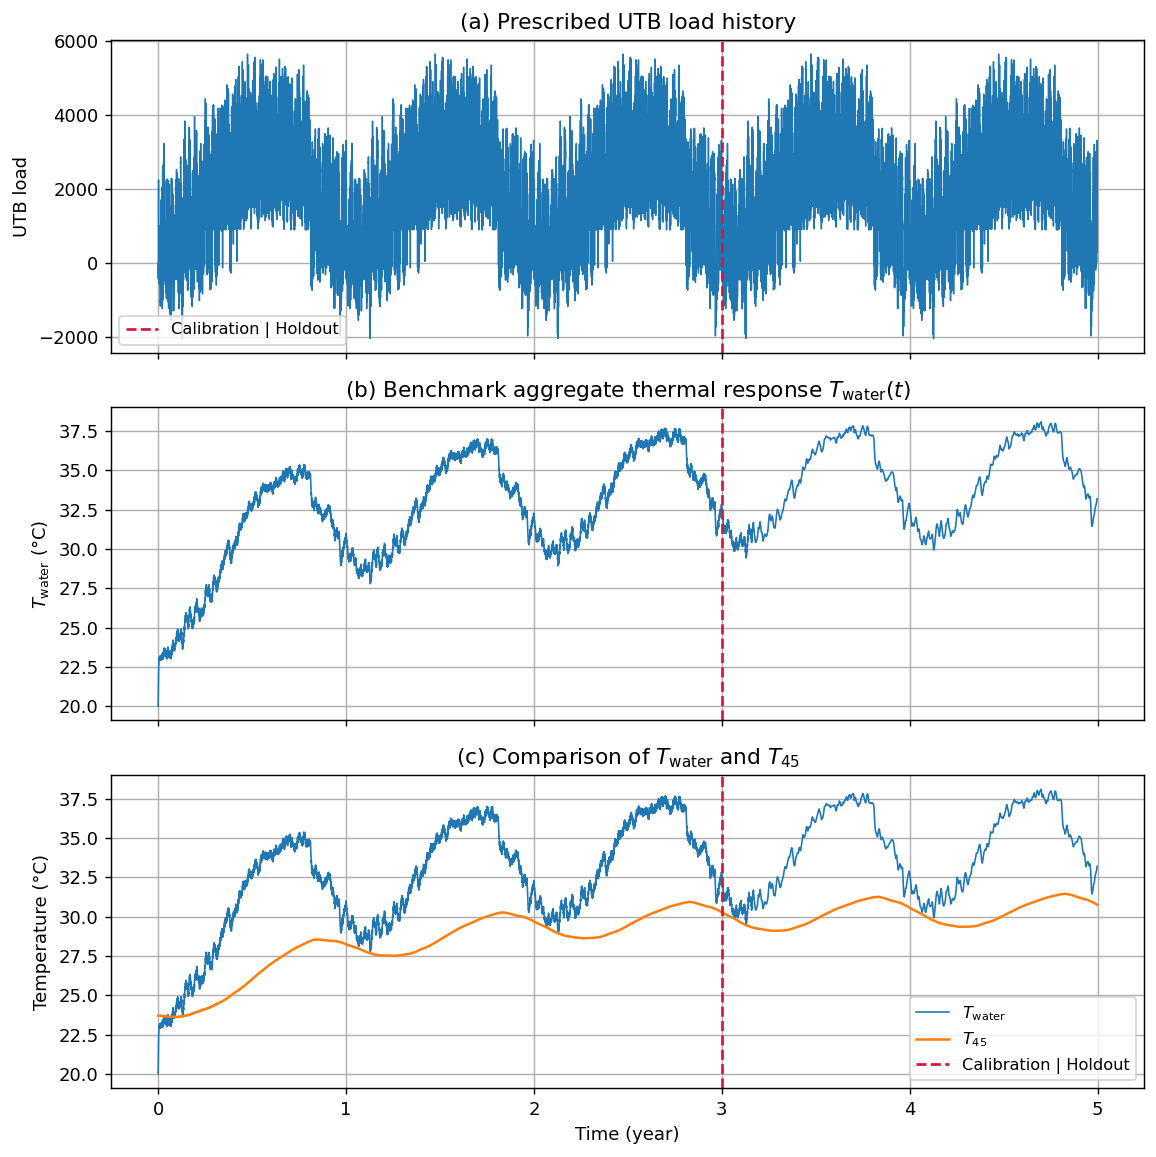

Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected/fig_benchmark_forcing_observables.png


In [ ]:
# Cell 10 — Figure: benchmark forcing and observables
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(merged["time_year"], merged["load"], lw=0.8)
axes[0].axvline(CALIB_YEARS, color="crimson", ls="--", lw=1.5, label="Calibration | Holdout")
axes[0].set_ylabel("UTB load")
axes[0].set_title("(a) Prescribed UTB load history")
axes[0].legend(fontsize=9)

axes[1].plot(merged["time_year"], merged["T_water"], lw=0.9)
axes[1].axvline(CALIB_YEARS, color="crimson", ls="--", lw=1.5)
axes[1].set_ylabel(r"$T_\mathrm{water}$ (°C)")
axes[1].set_title(r"(b) Benchmark aggregate thermal response $T_\mathrm{water}(t)$")

axes[2].plot(merged["time_year"], merged["T_water"], lw=0.9, label=r"$T_\mathrm{water}$")
axes[2].plot(merged["time_year"], merged["T_45"], lw=1.4, label=r"$T_{45}$")
axes[2].axvline(CALIB_YEARS, color="crimson", ls="--", lw=1.5, label="Calibration | Holdout")
axes[2].set_xlabel("Time (year)")
axes[2].set_ylabel("Temperature (°C)")
axes[2].set_title(r"(c) Comparison of $T_\mathrm{water}$ and $T_{45}$")
axes[2].legend(fontsize=9)

plt.tight_layout()

fig_path = os.path.join(OUT_DIR, "fig_benchmark_forcing_observables.png")
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


T_water first zero-crossing: 113.5 days
T_45 first zero-crossing: not found in range


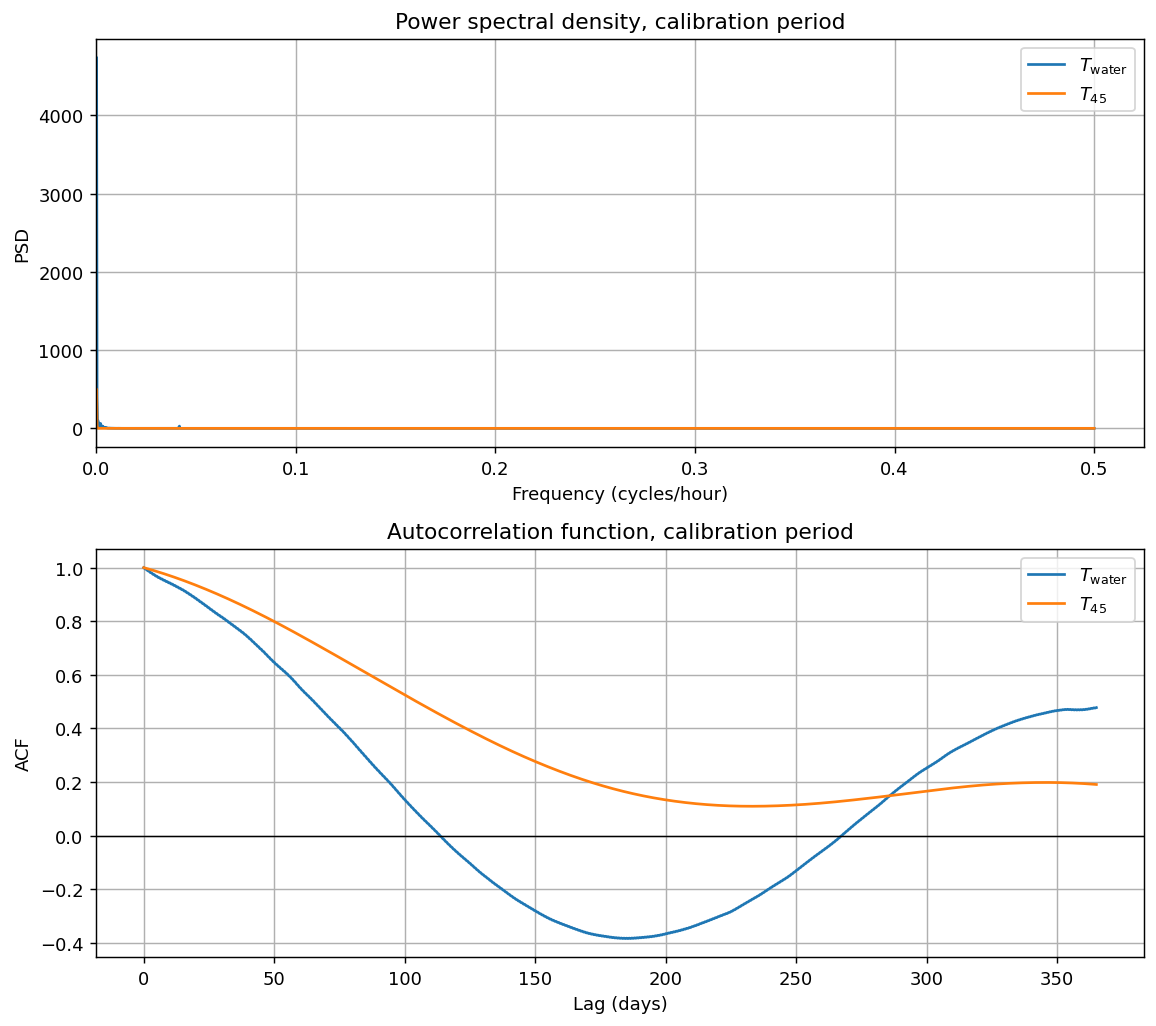

Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected/fig_psd_acf.png


In [ ]:
# Cell 11 — Spectral and autocorrelation diagnostics
def acf_numpy(x: np.ndarray, max_lag: int) -> np.ndarray:
    """
    Simple normalized autocorrelation function.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()

    denom = np.dot(x, x)

    if denom == 0:
        return np.full(max_lag + 1, np.nan)

    out = np.empty(max_lag + 1, dtype=float)
    out[0] = 1.0

    for lag in range(1, max_lag + 1):
        out[lag] = np.dot(x[:-lag], x[lag:]) / denom

    return out


def first_zero_crossing_hours(acf_vals: np.ndarray):
    idx = np.where(acf_vals <= 0)[0]
    idx = idx[idx > 0]

    if len(idx) == 0:
        return None

    return int(idx[0])


def fmt_days(hours):
    if hours is None:
        return "not found in range"
    return f"{hours / 24.0:.1f} days"


x_fast = d["X_c"]
x_slow = d["Y45_c"]

fs_h = 1.0  # one sample per hour

f_fast, p_fast = welch(
    x_fast - x_fast.mean(),
    fs=fs_h,
    nperseg=min(WELCH_NPERSEG, len(x_fast)),
)

f_slow, p_slow = welch(
    x_slow - x_slow.mean(),
    fs=fs_h,
    nperseg=min(WELCH_NPERSEG, len(x_slow)),
)

acf_fast = acf_numpy(x_fast, min(ACF_MAX_LAG_H, len(x_fast) - 1))
acf_slow = acf_numpy(x_slow, min(ACF_MAX_LAG_H, len(x_slow) - 1))

zc_fast_h = first_zero_crossing_hours(acf_fast)
zc_slow_h = first_zero_crossing_hours(acf_slow)

print("T_water first zero-crossing:", fmt_days(zc_fast_h))
print("T_45 first zero-crossing:", fmt_days(zc_slow_h))

fig, axes = plt.subplots(2, 1, figsize=(9, 8))

axes[0].plot(f_fast, p_fast, label=r"$T_\mathrm{water}$")
axes[0].plot(f_slow, p_slow, label=r"$T_{45}$")
axes[0].set_xlim(left=0)
axes[0].set_xlabel("Frequency (cycles/hour)")
axes[0].set_ylabel("PSD")
axes[0].set_title("Power spectral density, calibration period")
axes[0].legend()

lags_days_fast = np.arange(len(acf_fast)) / 24.0
lags_days_slow = np.arange(len(acf_slow)) / 24.0

axes[1].plot(lags_days_fast, acf_fast, label=r"$T_\mathrm{water}$")
axes[1].plot(lags_days_slow, acf_slow, label=r"$T_{45}$")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("ACF")
axes[1].set_title("Autocorrelation function, calibration period")
axes[1].legend()

plt.tight_layout()

fig_path = os.path.join(OUT_DIR, "fig_psd_acf.png")
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [ ]:
# Reduced-Order Model Definitions
# Cell 12 — One-state and exact cascade two-state ROMs
def simulate_1state(params, Fn_grid, x0):
    """
    One-state ROM:
        dx/dt = k*(g*F + b - x)

    Exact analytical update under piecewise-constant hourly forcing.
    """
    k, g, b = params

    if k <= 0:
        return None

    alpha = math.exp(-k * DT_H)

    x = np.empty(len(Fn_grid), dtype=float)
    x[0] = x0

    for i in range(1, len(Fn_grid)):
        U = g * Fn_grid[i - 1] + b
        x[i] = U + (x[i - 1] - U) * alpha

    return x


def simulate_2state_cascade(params, Fn_grid, x0, y0):
    """
    Cascade two-state ROM:
        dy/dt = c1*(g*F + b - y)
        dx/dt = c2*(y - x)

    Corrected exact analytical update under piecewise-constant hourly forcing.

    Important:
    This is an empirical cascade ROM. It should not automatically be interpreted as a
    literal physical decomposition of water and ground temperatures.
    """
    c1, c2, g, b = params

    if c1 <= 0 or c2 <= 0:
        return None, None

    a1 = math.exp(-c1 * DT_H)
    a2 = math.exp(-c2 * DT_H)

    A = a2

    if abs(c1 - c2) < 1e-14:
        B = c2 * DT_H * a2
    else:
        B = (c2 / (c1 - c2)) * (a2 - a1)

    C = 1.0 - A - B

    x = np.empty(len(Fn_grid), dtype=float)
    y = np.empty(len(Fn_grid), dtype=float)

    x[0] = x0
    y[0] = y0

    for i in range(1, len(Fn_grid)):
        U = g * Fn_grid[i - 1] + b

        y[i] = U + (y[i - 1] - U) * a1
        x[i] = A * x[i - 1] + B * y[i - 1] + C * U

    return x, y


print("Loaded exact one-state and exact cascade two-state ROMs.")


Loaded exact one-state and exact cascade two-state ROMs.


In [ ]:
# Cell 13 — Optional physically coupled two-state ROM
def simulate_2state_coupled(params, Fn_grid, x0, y0):
    """
    Physically coupled two-state ROM:
        dx/dt = c2*(g*F + b - x) + chi*(y - x)
        dy/dt = c1*(x - y)

    Here:
    - x is the fast/observable state.
    - y is the slow/internal state.
    - forcing acts directly on x.
    - x and y exchange heat through chi and c1.

    Exact analytical update under piecewise-constant hourly forcing.
    """
    c1, c2, chi, g, b = params

    if c1 <= 0 or c2 <= 0 or chi <= 0:
        return None, None

    # System matrix:
    # [dx/dt] = [-(c2+chi),  chi] [x] + [c2*U]
    # [dy/dt]   [ c1,       -c1] [y]   [0]
    m11 = -(c2 + chi)
    m12 = chi
    m21 = c1
    m22 = -c1

    tr = m11 + m22
    det = m11 * m22 - m12 * m21

    disc = tr**2 - 4.0 * det

    if disc < 0:
        return None, None

    sqrt_disc = math.sqrt(max(disc, 0.0))

    lam1 = 0.5 * (tr + sqrt_disc)
    lam2 = 0.5 * (tr - sqrt_disc)

    if abs(lam1 - lam2) < 1e-14:
        return None, None

    e1 = math.exp(lam1 * DT_H)
    e2 = math.exp(lam2 * DT_H)

    denom = lam1 - lam2

    # Matrix exponential using spectral formula:
    # exp(Mt) = ((M-lam2 I)e1 - (M-lam1 I)e2)/(lam1-lam2)
    expM_11 = ((m11 - lam2) * e1 - (m11 - lam1) * e2) / denom
    expM_12 = m12 * (e1 - e2) / denom
    expM_21 = m21 * (e1 - e2) / denom
    expM_22 = ((m22 - lam2) * e1 - (m22 - lam1) * e2) / denom

    # For constant U, steady state is x_ss = U, y_ss = U.
    Fx_gain = 1.0 - expM_11 - expM_12
    Fy_gain = 1.0 - expM_21 - expM_22

    x = np.empty(len(Fn_grid), dtype=float)
    y = np.empty(len(Fn_grid), dtype=float)

    x[0] = x0
    y[0] = y0

    for i in range(1, len(Fn_grid)):
        U = g * Fn_grid[i - 1] + b

        x_prev = x[i - 1]
        y_prev = y[i - 1]

        x[i] = expM_11 * x_prev + expM_12 * y_prev + Fx_gain * U
        y[i] = expM_21 * x_prev + expM_22 * y_prev + Fy_gain * U

    return x, y


print("Loaded optional exact physically coupled two-state ROM.")


Loaded optional exact physically coupled two-state ROM.


In [ ]:
# Cell 14 — Optimization bounds
BOUNDS_1 = [
    (1e-8, 1e-4),   # k
    (0.01, 10.0),   # g
    (-5.0, 5.0),    # b
]

BOUNDS_2_CASCADE_SEP = [
    (1e-8, 1e-5),   # c1
    (1e-6, 1e-4),   # c2
    (0.01, 10.0),   # g
    (-5.0, 5.0),    # b
]

BOUNDS_2_CASCADE_WIDE = [
    (1e-8, 1e-4),   # c1
    (1e-8, 1e-4),   # c2
    (0.01, 10.0),   # g
    (-5.0, 5.0),    # b
]

BOUNDS_2_COUPLED = [
    (1e-8, 1e-5),   # c1: slow exchange/internal rate
    (1e-7, 1e-3),   # c2: direct forcing response rate
    (1e-8, 1e-4),   # chi: coupling rate
    (0.01, 10.0),   # g
    (-5.0, 5.0),    # b
]

print("Bounds loaded.")


Bounds loaded.


In [ ]:
# Cell 15 — Metrics and calibration helpers
def rmse(y, yh):
    y = np.asarray(y, dtype=float)
    yh = np.asarray(yh, dtype=float)
    return float(np.sqrt(np.mean((y - yh) ** 2)))


def mae(y, yh):
    y = np.asarray(y, dtype=float)
    yh = np.asarray(yh, dtype=float)
    return float(np.mean(np.abs(y - yh)))


def r2_score(y, yh):
    y = np.asarray(y, dtype=float)
    yh = np.asarray(yh, dtype=float)

    den = np.sum((y - y.mean()) ** 2)

    if den == 0:
        return np.nan

    return float(1.0 - np.sum((y - yh) ** 2) / den)


def durbin_watson(resid):
    resid = np.asarray(resid, dtype=float)

    den = np.sum(resid ** 2)

    if den == 0:
        return np.nan

    num = np.sum(np.diff(resid) ** 2)

    return float(num / den)


def aic_bic_from_mse(mse, n, k):
    if mse <= 0:
        return np.nan, np.nan

    aic = n * np.log(mse) + 2 * k
    bic = n * np.log(mse) + k * np.log(n)

    return float(aic), float(bic)


def metrics_block(y, yh, k_params):
    resid = np.asarray(y) - np.asarray(yh)
    mse = np.mean(resid**2)

    r = {
        "rmse": rmse(y, yh),
        "mae": mae(y, yh),
        "r2": r2_score(y, yh),
        "dw": durbin_watson(resid),
    }

    r["aic"], r["bic"] = aic_bic_from_mse(mse, len(y), k_params)

    return r


def combined_rmse(mx, my, wx=0.5, wy=0.5):
    return float(np.sqrt(wx * mx["rmse"] ** 2 + wy * my["rmse"] ** 2))


def calibrate(
    obj_fn,
    bounds,
    n_seeds=10,
    maxiter=1000,
    popsize=20,
    label="model",
):
    """
    Differential evolution calibration with multiple independent seeds.
    """
    best_res = None
    vals = []

    for seed in range(n_seeds):
        res = differential_evolution(
            obj_fn,
            bounds=bounds,
            seed=seed,
            maxiter=maxiter,
            popsize=popsize,
            tol=DE_TOL,
            polish=True,
            updating="deferred",
            workers=1,
        )

        vals.append(res.fun)

        print(f"[{label}] seed {seed:02d}: obj={res.fun:.6e}")

        if best_res is None or res.fun < best_res.fun:
            best_res = res

    vals = np.asarray(vals, dtype=float)

    sigma_pct = 100.0 * np.std(vals, ddof=0) / np.mean(vals)

    print(f"[{label}] DONE — best={best_res.fun:.6e}, inter-seed σ={sigma_pct:.4f}%")

    return best_res.x, best_res.fun, sigma_pct


print("Metrics and calibration helpers loaded.")


Metrics and calibration helpers loaded.


In [ ]:
# Baseline Calibrations
# Cell 16 — Run baseline calibrations
Fn_c = d["Fn_c"]
Xn_c = d["Xn_c"]
Y45n_c = d["Y45n_c"]

x0_c = Xn_c[0]
y0_c = Y45n_c[0]

# =========================
# ONE-STATE MODEL
# =========================

print("=== (A) ONE-STATE MODEL ===")

def obj_1(p):
    xh = simulate_1state(p, Fn_c, x0_c)

    if xh is None:
        return 1e12

    return float(np.mean((xh - Xn_c) ** 2))


p1, obj1, sig1 = calibrate(
    obj_1,
    BOUNDS_1,
    n_seeds=N_SEEDS_BASE,
    maxiter=MAXITER_BASE,
    popsize=POPSIZE_BASE,
    label="1-state",
)

# =========================
# CASCADE TWO-STATE SINGLE-OUTPUT
# =========================

print("\n=== (B) CASCADE TWO-STATE SINGLE-OUTPUT ===")

def obj_2cascade_single(p):
    xh, yh = simulate_2state_cascade(p, Fn_c, x0_c, y0_c)

    if xh is None:
        return 1e12

    return float(np.mean((xh - Xn_c) ** 2))


p2s, obj2s, sig2s = calibrate(
    obj_2cascade_single,
    BOUNDS_2_CASCADE_SEP,
    n_seeds=N_SEEDS_BASE,
    maxiter=MAXITER_BASE,
    popsize=POPSIZE_BASE,
    label="2-state cascade single",
)

# =========================
# CASCADE TWO-STATE JOINT
# =========================

print("\n=== (C) CASCADE TWO-STATE JOINT ===")

def obj_2cascade_joint(p):
    xh, yh = simulate_2state_cascade(p, Fn_c, x0_c, y0_c)

    if xh is None:
        return 1e12

    ex = np.mean((xh - Xn_c) ** 2)
    ey = np.mean((yh - Y45n_c) ** 2)

    return float(0.5 * ex + 0.5 * ey)


p2j, obj2j, sig2j = calibrate(
    obj_2cascade_joint,
    BOUNDS_2_CASCADE_SEP,
    n_seeds=N_SEEDS_BASE,
    maxiter=MAXITER_BASE,
    popsize=POPSIZE_BASE,
    label="2-state cascade joint",
)

print("\n=== BASELINE PARAMETER SUMMARY ===")
print(f"One-state: k={p1[0]:.6e}, g={p1[1]:.6f}, b={p1[2]:.6f}, σ={sig1:.4f}%")
print(
    f"2-state cascade single: c1={p2s[0]:.6e}, c2={p2s[1]:.6e}, "
    f"c2/c1={p2s[1]/p2s[0]:.2f}, g={p2s[2]:.6f}, b={p2s[3]:.6f}, σ={sig2s:.4f}%"
)
print(
    f"2-state cascade joint: c1={p2j[0]:.6e}, c2={p2j[1]:.6e}, "
    f"c2/c1={p2j[1]/p2j[0]:.2f}, g={p2j[2]:.6f}, b={p2j[3]:.6f}, σ={sig2j:.4f}%"
)

print("\nTimescales for cascade joint:")
print(f"tau1 = {1.0 / (p2j[0] * 86400.0):.2f} days")
print(f"tau2 = {1.0 / (p2j[1] * 3600.0):.2f} hours")


=== (A) ONE-STATE MODEL ===
[1-state] seed 00: obj=9.818811e-02
[1-state] seed 01: obj=9.818811e-02
[1-state] seed 02: obj=9.818811e-02
[1-state] seed 03: obj=9.818811e-02
[1-state] seed 04: obj=9.818811e-02
[1-state] seed 05: obj=9.818811e-02
[1-state] seed 06: obj=9.818811e-02
[1-state] seed 07: obj=9.818811e-02
[1-state] seed 08: obj=9.818811e-02
[1-state] seed 09: obj=9.818811e-02
[1-state] DONE — best=9.818811e-02, inter-seed σ=0.0000%

=== (B) CASCADE TWO-STATE SINGLE-OUTPUT ===
[2-state cascade single] seed 00: obj=1.227501e-01
[2-state cascade single] seed 01: obj=1.227501e-01
[2-state cascade single] seed 02: obj=1.227501e-01
[2-state cascade single] seed 03: obj=1.227501e-01
[2-state cascade single] seed 04: obj=1.227501e-01
[2-state cascade single] seed 05: obj=1.227501e-01
[2-state cascade single] seed 06: obj=1.227501e-01
[2-state cascade single] seed 07: obj=1.227501e-01
[2-state cascade single] seed 08: obj=1.227501e-01
[2-state cascade single] seed 09: obj=1.227501e-01


In [ ]:
# Cell 17 — Optional physically coupled model calibration
RUN_COUPLED_MODEL = True

if RUN_COUPLED_MODEL:
    print("=== (D) PHYSICALLY COUPLED TWO-STATE JOINT MODEL ===")

    def obj_2coupled_joint(p):
        xh, yh = simulate_2state_coupled(p, Fn_c, x0_c, y0_c)

        if xh is None:
            return 1e12

        ex = np.mean((xh - Xn_c) ** 2)
        ey = np.mean((yh - Y45n_c) ** 2)

        return float(0.5 * ex + 0.5 * ey)

    p2c, obj2c, sig2c = calibrate(
        obj_2coupled_joint,
        BOUNDS_2_COUPLED,
        n_seeds=N_SEEDS_BASE,
        maxiter=MAXITER_BASE,
        popsize=POPSIZE_BASE,
        label="2-state coupled joint",
    )

    print(
        f"2-state coupled joint: c1={p2c[0]:.6e}, c2={p2c[1]:.6e}, "
        f"chi={p2c[2]:.6e}, g={p2c[3]:.6f}, b={p2c[4]:.6f}, σ={sig2c:.4f}%"
    )

else:
    p2c, obj2c, sig2c = None, None, None
    print("Coupled model skipped.")


=== (D) PHYSICALLY COUPLED TWO-STATE JOINT MODEL ===
[2-state coupled joint] seed 00: obj=2.052064e-02
[2-state coupled joint] seed 01: obj=2.052064e-02
[2-state coupled joint] seed 02: obj=2.052064e-02
[2-state coupled joint] seed 03: obj=2.052064e-02
[2-state coupled joint] seed 04: obj=2.052064e-02
[2-state coupled joint] seed 05: obj=2.052064e-02
[2-state coupled joint] seed 06: obj=2.052064e-02
[2-state coupled joint] seed 07: obj=2.052064e-02
[2-state coupled joint] seed 08: obj=2.052064e-02
[2-state coupled joint] seed 09: obj=2.052064e-02
[2-state coupled joint] DONE — best=2.052064e-02, inter-seed σ=0.0000%
2-state coupled joint: c1=1.430643e-07, c2=7.404148e-07, chi=1.629452e-06, g=3.033343, b=0.641382, σ=0.0000%


In [ ]:
# Evaluation
# Cell 18 — Evaluate calibration and holdout predictions
ev = {}

# =========================
# ONE-STATE
# =========================

x1c_n = simulate_1state(p1, d["Fn_c"], d["Xn_c"][0])
x1h_n = simulate_1state(p1, d["Fn_h"], x1c_n[-1])

ev["x1c_n"] = x1c_n
ev["x1h_n"] = x1h_n
ev["x1c"] = x1c_n * d["Xs"] + d["Xm"]
ev["x1h"] = x1h_n * d["Xs"] + d["Xm"]

# =========================
# CASCADE TWO-STATE SINGLE-OUTPUT
# =========================

x2s_c_n, y2s_c_n = simulate_2state_cascade(
    p2s,
    d["Fn_c"],
    d["Xn_c"][0],
    d["Y45n_c"][0],
)

x2s_h_n, y2s_h_n = simulate_2state_cascade(
    p2s,
    d["Fn_h"],
    x2s_c_n[-1],
    y2s_c_n[-1],
)

ev["x2s_c_n"] = x2s_c_n
ev["x2s_h_n"] = x2s_h_n
ev["y2s_c_n"] = y2s_c_n
ev["y2s_h_n"] = y2s_h_n

ev["x2s_c"] = x2s_c_n * d["Xs"] + d["Xm"]
ev["x2s_h"] = x2s_h_n * d["Xs"] + d["Xm"]

# =========================
# CASCADE TWO-STATE JOINT
# =========================

x2j_c_n, y2j_c_n = simulate_2state_cascade(
    p2j,
    d["Fn_c"],
    d["Xn_c"][0],
    d["Y45n_c"][0],
)

x2j_h_n, y2j_h_n = simulate_2state_cascade(
    p2j,
    d["Fn_h"],
    x2j_c_n[-1],
    y2j_c_n[-1],
)

ev["x2j_c_n"] = x2j_c_n
ev["x2j_h_n"] = x2j_h_n
ev["y2j_c_n"] = y2j_c_n
ev["y2j_h_n"] = y2j_h_n

ev["x2j_c"] = x2j_c_n * d["Xs"] + d["Xm"]
ev["x2j_h"] = x2j_h_n * d["Xs"] + d["Xm"]
ev["y2j_c"] = y2j_c_n * d["Y45s"] + d["Y45m"]
ev["y2j_h"] = y2j_h_n * d["Y45s"] + d["Y45m"]

# =========================
# COUPLED TWO-STATE JOINT
# =========================

if RUN_COUPLED_MODEL:
    x2c_c_n, y2c_c_n = simulate_2state_coupled(
        p2c,
        d["Fn_c"],
        d["Xn_c"][0],
        d["Y45n_c"][0],
    )

    x2c_h_n, y2c_h_n = simulate_2state_coupled(
        p2c,
        d["Fn_h"],
        x2c_c_n[-1],
        y2c_c_n[-1],
    )

    ev["x2c_c_n"] = x2c_c_n
    ev["x2c_h_n"] = x2c_h_n
    ev["y2c_c_n"] = y2c_c_n
    ev["y2c_h_n"] = y2c_h_n

    ev["x2c_c"] = x2c_c_n * d["Xs"] + d["Xm"]
    ev["x2c_h"] = x2c_h_n * d["Xs"] + d["Xm"]
    ev["y2c_c"] = y2c_c_n * d["Y45s"] + d["Y45m"]
    ev["y2c_h"] = y2c_h_n * d["Y45s"] + d["Y45m"]

print("Evaluation trajectories generated.")


Evaluation trajectories generated.


In [ ]:
# Cell 19 — Compute metrics
metrics = {}

# One-state
metrics["m1x_c"] = metrics_block(d["X_c"], ev["x1c"], 3)
metrics["m1x_h"] = metrics_block(d["X_h"], ev["x1h"], 3)

# Same one-state trajectory compared with T45 for structural adequacy check
metrics["m1y_c"] = metrics_block(d["Y45_c"], ev["x1c"], 3)
metrics["m1y_h"] = metrics_block(d["Y45_h"], ev["x1h"], 3)

# Cascade single-output
metrics["m2sx_c"] = metrics_block(d["X_c"], ev["x2s_c"], 4)
metrics["m2sx_h"] = metrics_block(d["X_h"], ev["x2s_h"], 4)

# Cascade joint
metrics["m2jx_c"] = metrics_block(d["X_c"], ev["x2j_c"], 4)
metrics["m2jx_h"] = metrics_block(d["X_h"], ev["x2j_h"], 4)
metrics["m2jy_c"] = metrics_block(d["Y45_c"], ev["y2j_c"], 4)
metrics["m2jy_h"] = metrics_block(d["Y45_h"], ev["y2j_h"], 4)

# Coupled joint
if RUN_COUPLED_MODEL:
    metrics["m2cx_c"] = metrics_block(d["X_c"], ev["x2c_c"], 5)
    metrics["m2cx_h"] = metrics_block(d["X_h"], ev["x2c_h"], 5)
    metrics["m2cy_c"] = metrics_block(d["Y45_c"], ev["y2c_c"], 5)
    metrics["m2cy_h"] = metrics_block(d["Y45_h"], ev["y2c_h"], 5)

print("=== ONE-STATE MODEL ===")
print("Calibration:")
print(metrics["m1x_c"])
print(metrics["m1y_c"])
print("Holdout:")
print(metrics["m1x_h"])
print(metrics["m1y_h"])

print("\n=== CASCADE TWO-STATE SINGLE-OUTPUT ===")
print("Calibration:")
print(metrics["m2sx_c"])
print("Holdout:")
print(metrics["m2sx_h"])

print("\n=== CASCADE TWO-STATE JOINT ===")
print("Calibration:")
print(metrics["m2jx_c"])
print(metrics["m2jy_c"])
print("Holdout:")
print(metrics["m2jx_h"])
print(metrics["m2jy_h"])

if RUN_COUPLED_MODEL:
    print("\n=== COUPLED TWO-STATE JOINT ===")
    print("Calibration:")
    print(metrics["m2cx_c"])
    print(metrics["m2cy_c"])
    print("Holdout:")
    print(metrics["m2cx_h"])
    print(metrics["m2cy_h"])


=== ONE-STATE MODEL ===
Calibration:
{'rmse': 1.0880612799534048, 'mae': 0.9344906474408281, 'r2': 0.9018118888947453, 'dw': 0.000688190055085542, 'aic': 4444.969349699068, 'bic': 4469.501094208008}
{'rmse': 4.777968244657556, 'mae': 4.198269656310746, 'r2': -4.564103881742009, 'dw': 6.753725255801142e-07, 'aic': 82266.95412165218, 'bic': 82291.48586616112}
Holdout:
{'rmse': 1.5817224799347571, 'mae': 1.4563234518340964, 'r2': 0.6158292486589392, 'dw': 4.118044657082668e-05, 'aic': 16055.839121762596, 'bic': 16079.149333079884}
{'rmse': 3.2317597154382716, 'mae': 2.6329526746354106, 'r2': -17.41695634407871, 'dw': 1.283529038517419e-06, 'aic': 41066.62984201864, 'bic': 41089.94005333593}

=== CASCADE TWO-STATE SINGLE-OUTPUT ===
Calibration:
{'rmse': 1.2165635547887075, 'mae': 1.0561060845216146, 'r2': 0.8772499160137306, 'dw': 0.0006643925650279412, 'aic': 10318.400499002317, 'bic': 10351.109491680903}
Holdout:
{'rmse': 1.702746357349869, 'mae': 1.541873626014436, 'r2': 0.5547912997164

In [ ]:
# Cell 20 — Compact metric printout
def print_metric_line(name, period, mx=None, my=None):
    print(f"{name:<32} {period:<12}", end="")

    if mx is not None:
        print(
            f" T_water: RMSE={mx['rmse']:.3f} °C, "
            f"MAE={mx['mae']:.3f} °C, R²={mx['r2']:.4f}",
            end=""
        )

    if my is not None:
        print(
            f" | T45: RMSE={my['rmse']:.3f} °C, "
            f"MAE={my['mae']:.3f} °C, R²={my['r2']:.4f}",
            end=""
        )

        if mx is not None:
            print(f" | Combined RMSE={combined_rmse(mx, my):.3f}", end="")

    print()


print("=" * 120)
print("PERFORMANCE SUMMARY")
print("=" * 120)

print_metric_line("One-state", "Calibration", metrics["m1x_c"], metrics["m1y_c"])
print_metric_line("One-state", "Holdout", metrics["m1x_h"], metrics["m1y_h"])

print_metric_line("Cascade single-output", "Calibration", metrics["m2sx_c"], None)
print_metric_line("Cascade single-output", "Holdout", metrics["m2sx_h"], None)

print_metric_line("Cascade joint", "Calibration", metrics["m2jx_c"], metrics["m2jy_c"])
print_metric_line("Cascade joint", "Holdout", metrics["m2jx_h"], metrics["m2jy_h"])

if RUN_COUPLED_MODEL:
    print_metric_line("Coupled joint", "Calibration", metrics["m2cx_c"], metrics["m2cy_c"])
    print_metric_line("Coupled joint", "Holdout", metrics["m2cx_h"], metrics["m2cy_h"])


PERFORMANCE SUMMARY
One-state                        Calibration  T_water: RMSE=1.088 °C, MAE=0.934 °C, R²=0.9018 | T45: RMSE=4.778 °C, MAE=4.198 °C, R²=-4.5641 | Combined RMSE=3.465
One-state                        Holdout      T_water: RMSE=1.582 °C, MAE=1.456 °C, R²=0.6158 | T45: RMSE=3.232 °C, MAE=2.633 °C, R²=-17.4170 | Combined RMSE=2.544
Cascade single-output            Calibration  T_water: RMSE=1.217 °C, MAE=1.056 °C, R²=0.8772
Cascade single-output            Holdout      T_water: RMSE=1.703 °C, MAE=1.542 °C, R²=0.5548
Cascade joint                    Calibration  T_water: RMSE=1.847 °C, MAE=1.639 °C, R²=0.7169 | T45: RMSE=0.495 °C, MAE=0.415 °C, R²=0.9402 | Combined RMSE=1.352
Cascade joint                    Holdout      T_water: RMSE=1.843 °C, MAE=1.666 °C, R²=0.4785 | T45: RMSE=1.048 °C, MAE=1.027 °C, R²=-0.9349 | Combined RMSE=1.499
Coupled joint                    Calibration  T_water: RMSE=0.491 °C, MAE=0.423 °C, R²=0.9800 | T45: RMSE=0.294 °C, MAE=0.246 °C, R²=0.9789 

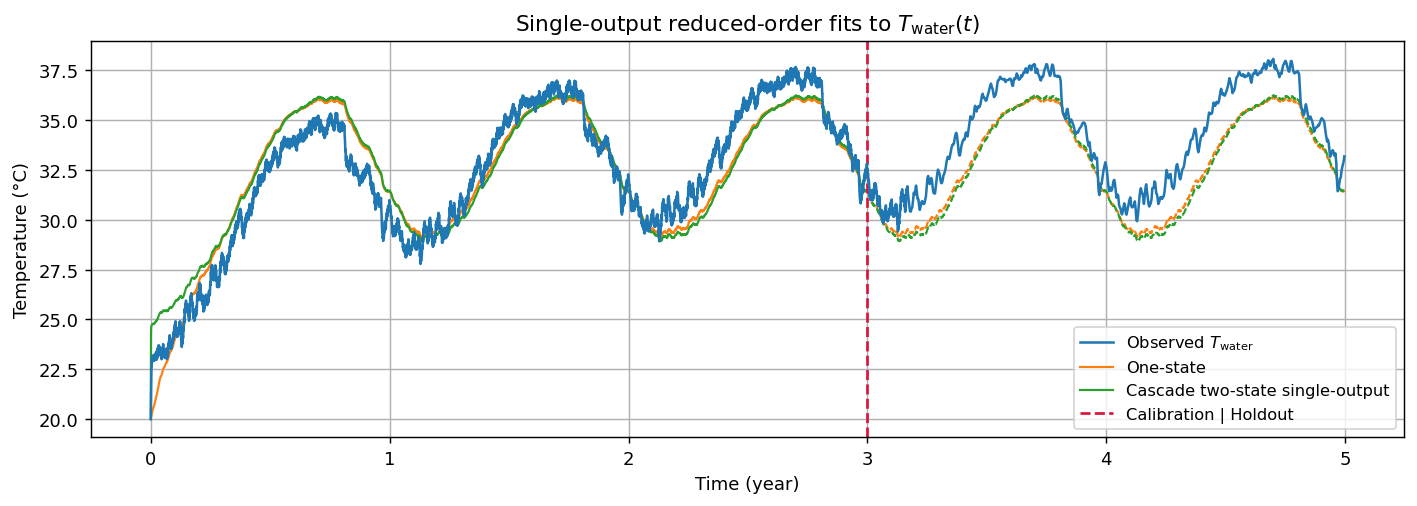

Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected/fig_single_output_Twater.png


In [ ]:
# Figures
# Cell 21 — Figure: single-output comparison on T_water
fig, ax = plt.subplots(figsize=(11, 4))

t_all = np.concatenate([d["tyr_c"], d["tyr_h"]])
x_all = np.concatenate([d["X_c"], d["X_h"]])

ax.plot(t_all, x_all, lw=1.4, label=r"Observed $T_\mathrm{water}$", zorder=3)

ax.plot(d["tyr_c"], ev["x1c"], lw=1.2, label="One-state")
ax.plot(d["tyr_h"], ev["x1h"], lw=1.2, ls="--", color=ax.lines[-1].get_color())

ax.plot(d["tyr_c"], ev["x2s_c"], lw=1.2, label="Cascade two-state single-output")
ax.plot(d["tyr_h"], ev["x2s_h"], lw=1.2, ls="--", color=ax.lines[-1].get_color())

ax.axvline(CALIB_YEARS, color="crimson", ls="--", lw=1.5, label="Calibration | Holdout")

ax.set_xlabel("Time (year)")
ax.set_ylabel("Temperature (°C)")
ax.set_title(r"Single-output reduced-order fits to $T_\mathrm{water}(t)$")
ax.legend(fontsize=9)

plt.tight_layout()

fig_path = os.path.join(OUT_DIR, "fig_single_output_Twater.png")
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


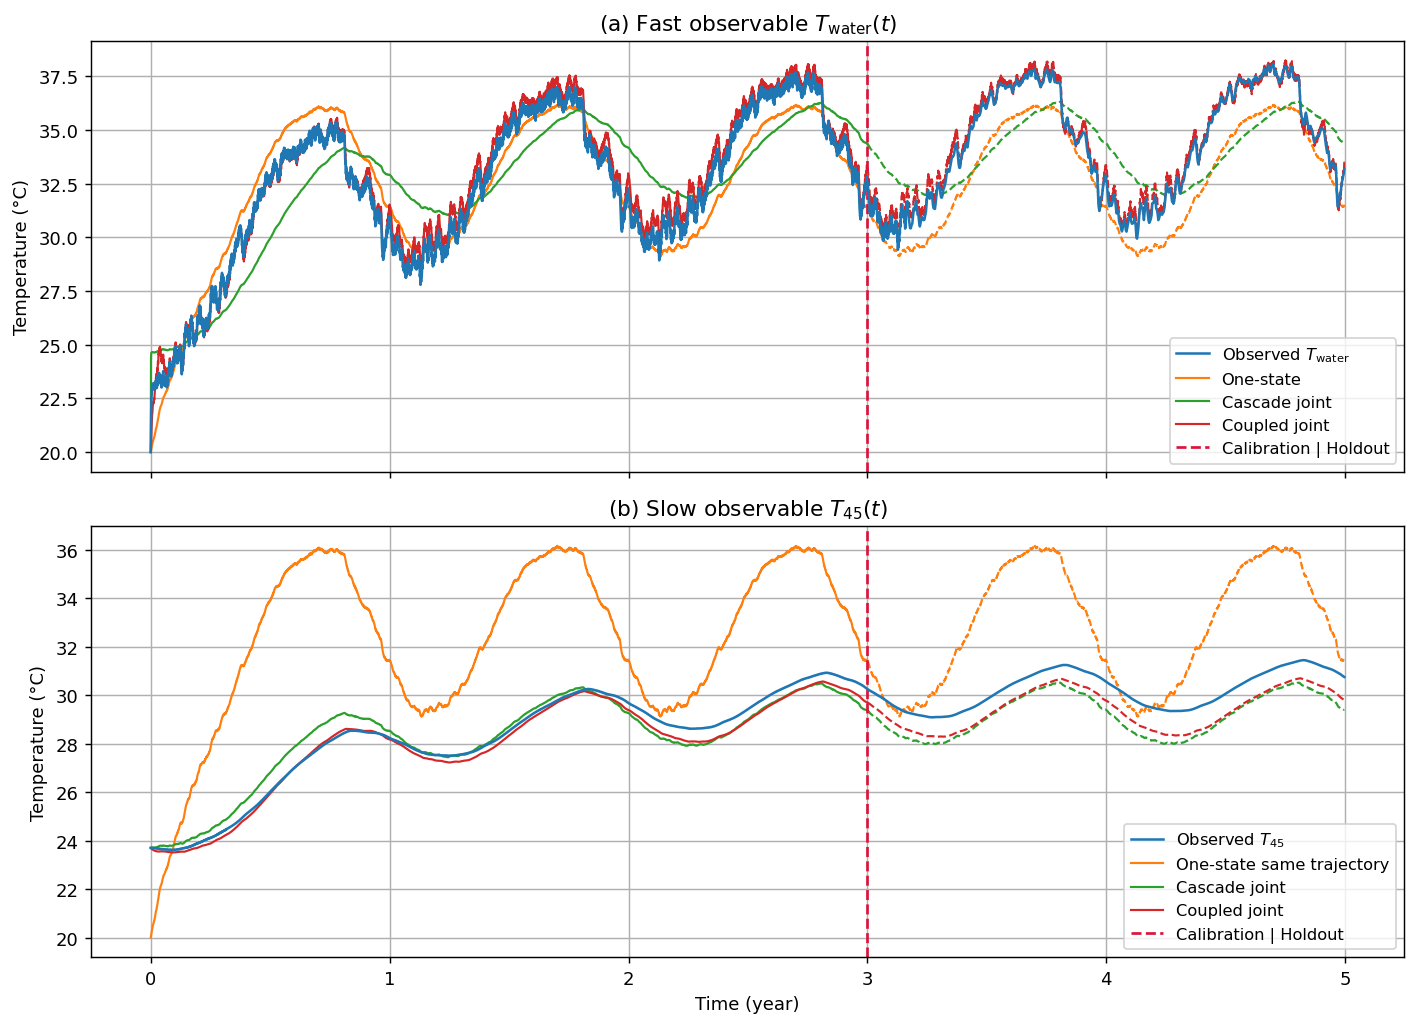

Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected/fig_joint_fast_slow.png


In [ ]:
# Cell 22 — Figure: joint fast–slow comparison
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# T_water
axes[0].plot(
    np.concatenate([d["tyr_c"], d["tyr_h"]]),
    np.concatenate([d["X_c"], d["X_h"]]),
    lw=1.4,
    label=r"Observed $T_\mathrm{water}$",
    zorder=3,
)

axes[0].plot(d["tyr_c"], ev["x1c"], lw=1.2, label="One-state")
axes[0].plot(d["tyr_h"], ev["x1h"], lw=1.2, ls="--", color=axes[0].lines[-1].get_color())

axes[0].plot(d["tyr_c"], ev["x2j_c"], lw=1.2, label="Cascade joint")
axes[0].plot(d["tyr_h"], ev["x2j_h"], lw=1.2, ls="--", color=axes[0].lines[-1].get_color())

if RUN_COUPLED_MODEL:
    axes[0].plot(d["tyr_c"], ev["x2c_c"], lw=1.2, label="Coupled joint")
    axes[0].plot(d["tyr_h"], ev["x2c_h"], lw=1.2, ls="--", color=axes[0].lines[-1].get_color())

axes[0].axvline(CALIB_YEARS, color="crimson", ls="--", lw=1.5, label="Calibration | Holdout")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title(r"(a) Fast observable $T_\mathrm{water}(t)$")
axes[0].legend(fontsize=9)

# T45
axes[1].plot(
    np.concatenate([d["tyr_c"], d["tyr_h"]]),
    np.concatenate([d["Y45_c"], d["Y45_h"]]),
    lw=1.4,
    label=r"Observed $T_{45}$",
    zorder=3,
)

axes[1].plot(d["tyr_c"], ev["x1c"], lw=1.2, label="One-state same trajectory")
axes[1].plot(d["tyr_h"], ev["x1h"], lw=1.2, ls="--", color=axes[1].lines[-1].get_color())

axes[1].plot(d["tyr_c"], ev["y2j_c"], lw=1.2, label="Cascade joint")
axes[1].plot(d["tyr_h"], ev["y2j_h"], lw=1.2, ls="--", color=axes[1].lines[-1].get_color())

if RUN_COUPLED_MODEL:
    axes[1].plot(d["tyr_c"], ev["y2c_c"], lw=1.2, label="Coupled joint")
    axes[1].plot(d["tyr_h"], ev["y2c_h"], lw=1.2, ls="--", color=axes[1].lines[-1].get_color())

axes[1].axvline(CALIB_YEARS, color="crimson", ls="--", lw=1.5, label="Calibration | Holdout")
axes[1].set_xlabel("Time (year)")
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_title(r"(b) Slow observable $T_{45}(t)$")
axes[1].legend(fontsize=9)

plt.tight_layout()

fig_path = os.path.join(OUT_DIR, "fig_joint_fast_slow.png")
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [ ]:
# Corrected Bootstrap
# Cell 23 — Corrected bootstrap confidence intervals
def bootstrap_rmse_r2(y_true, y_hat, n_boot=500, seed=1234):
    """
    Approximate IID residual bootstrap for fixed-prediction metric uncertainty.

    Corrected logic:
    - Construct pseudo-data yb = y_hat + resampled residuals.
    - Compare yb with fixed prediction y_hat.

    This does not re-fit the model.
    This does not preserve temporal dependence.
    Therefore, intervals are descriptive/approximate, not full predictive uncertainty intervals.
    """
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true, dtype=float)
    y_hat = np.asarray(y_hat, dtype=float)

    resid = y_true - y_hat

    rmse_vals = []
    r2_vals = []

    for _ in range(n_boot):
        rb = rng.choice(resid, size=len(resid), replace=True)
        yb = y_hat + rb

        rmse_vals.append(rmse(yb, y_hat))
        r2_vals.append(r2_score(yb, y_hat))

    rmse_ci = (
        np.percentile(rmse_vals, 2.5),
        np.percentile(rmse_vals, 97.5),
    )

    r2_ci = (
        np.percentile(r2_vals, 2.5),
        np.percentile(r2_vals, 97.5),
    )

    return rmse_ci, r2_ci


print("=== CORRECTED BOOTSTRAP 95% INTERVALS, CALIBRATION PERIOD ===")

bootstrap_results = {}

bootstrap_results["one_state_Twater"] = bootstrap_rmse_r2(
    d["X_c"],
    ev["x1c"],
    n_boot=N_BOOT,
    seed=RNG_BOOT,
)

bootstrap_results["cascade_joint_Twater"] = bootstrap_rmse_r2(
    d["X_c"],
    ev["x2j_c"],
    n_boot=N_BOOT,
    seed=RNG_BOOT + 1,
)

bootstrap_results["cascade_joint_T45"] = bootstrap_rmse_r2(
    d["Y45_c"],
    ev["y2j_c"],
    n_boot=N_BOOT,
    seed=RNG_BOOT + 2,
)

if RUN_COUPLED_MODEL:
    bootstrap_results["coupled_joint_Twater"] = bootstrap_rmse_r2(
        d["X_c"],
        ev["x2c_c"],
        n_boot=N_BOOT,
        seed=RNG_BOOT + 3,
    )

    bootstrap_results["coupled_joint_T45"] = bootstrap_rmse_r2(
        d["Y45_c"],
        ev["y2c_c"],
        n_boot=N_BOOT,
        seed=RNG_BOOT + 4,
    )

for key, (rmse_ci, r2_ci) in bootstrap_results.items():
    print(
        f"{key:<24} "
        f"RMSE CI=[{rmse_ci[0]:.3f}, {rmse_ci[1]:.3f}], "
        f"R² CI=[{r2_ci[0]:.4f}, {r2_ci[1]:.4f}]"
    )


=== CORRECTED BOOTSTRAP 95% INTERVALS, CALIBRATION PERIOD ===
one_state_Twater         RMSE CI=[1.082, 1.095], R² CI=[0.9036, 0.9061]
cascade_joint_Twater     RMSE CI=[1.837, 1.858], R² CI=[0.7333, 0.7402]
cascade_joint_T45        RMSE CI=[0.493, 0.499], R² CI=[0.9287, 0.9305]
coupled_joint_Twater     RMSE CI=[0.488, 0.494], R² CI=[0.9805, 0.9809]
coupled_joint_T45        RMSE CI=[0.292, 0.296], R² CI=[0.9775, 0.9781]


In [ ]:
# Automatic Table Generation
# Cell 24 — Generate manuscript-ready Table 1
table1_rows = [
    {
        "Model / configuration": "One-state (T_water)",
        "k_or_c1_s^-1": p1[0],
        "c2_s^-1": np.nan,
        "chi_s^-1": np.nan,
        "c2_over_c1": np.nan,
        "g": p1[1],
        "b": p1[2],
        "inter_seed_sigma_percent": sig1,
    },
    {
        "Model / configuration": "Cascade two-state single-output (T_water)",
        "k_or_c1_s^-1": p2s[0],
        "c2_s^-1": p2s[1],
        "chi_s^-1": np.nan,
        "c2_over_c1": p2s[1] / p2s[0],
        "g": p2s[2],
        "b": p2s[3],
        "inter_seed_sigma_percent": sig2s,
    },
    {
        "Model / configuration": "Cascade two-state joint (T_water + T45)",
        "k_or_c1_s^-1": p2j[0],
        "c2_s^-1": p2j[1],
        "chi_s^-1": np.nan,
        "c2_over_c1": p2j[1] / p2j[0],
        "g": p2j[2],
        "b": p2j[3],
        "inter_seed_sigma_percent": sig2j,
    },
]

if RUN_COUPLED_MODEL:
    table1_rows.append(
        {
            "Model / configuration": "Coupled two-state joint (T_water + T45)",
            "k_or_c1_s^-1": p2c[0],
            "c2_s^-1": p2c[1],
            "chi_s^-1": p2c[2],
            "c2_over_c1": p2c[1] / p2c[0],
            "g": p2c[3],
            "b": p2c[4],
            "inter_seed_sigma_percent": sig2c,
        }
    )

table1 = pd.DataFrame(table1_rows)

table1_path = os.path.join(OUT_DIR, "table1_parameters_corrected.csv")
table1.to_csv(table1_path, index=False)

display(table1)

print("Saved Table 1:", table1_path)


,Model / configuration,k_or_c1_s^-1,c2_s^-1,chi_s^-1,c2_over_c1,g,b,inter_seed_sigma_percent
0,One-state (T_water),2.296121e-07,NaN,NaN,NaN,1.493339,0.146970,3.532215e-07
1,Cascade two-state single-output (T_water),2.093918e-07,9.999973e-05,NaN,477.572249,1.633529,0.123099,1.155277e-06
2,Cascade two-state joint (T_water + T45),5.950676e-08,9.999999e-05,NaN,1680.481180,2.367012,0.505924,1.722397e-07
3,Coupled two-state joint (T_water + T45),1.430643e-07,7.404148e-07,0.000002,5.175400,3.033343,0.641382,7.309489e-07


Saved Table 1: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected/table1_parameters_corrected.csv


In [ ]:
# Cell 25 — Generate manuscript-ready Table 2
table2_rows = [
    {
        "Model / mode": "One-state",
        "Period": "Calibration",
        "RMSE_Twater_C": metrics["m1x_c"]["rmse"],
        "R2_Twater": metrics["m1x_c"]["r2"],
        "RMSE_T45_C": metrics["m1y_c"]["rmse"],
        "R2_T45": metrics["m1y_c"]["r2"],
        "Combined_RMSE": combined_rmse(metrics["m1x_c"], metrics["m1y_c"]),
    },
    {
        "Model / mode": "One-state",
        "Period": "Holdout",
        "RMSE_Twater_C": metrics["m1x_h"]["rmse"],
        "R2_Twater": metrics["m1x_h"]["r2"],
        "RMSE_T45_C": metrics["m1y_h"]["rmse"],
        "R2_T45": metrics["m1y_h"]["r2"],
        "Combined_RMSE": combined_rmse(metrics["m1x_h"], metrics["m1y_h"]),
    },
    {
        "Model / mode": "Cascade two-state single-output",
        "Period": "Calibration",
        "RMSE_Twater_C": metrics["m2sx_c"]["rmse"],
        "R2_Twater": metrics["m2sx_c"]["r2"],
        "RMSE_T45_C": np.nan,
        "R2_T45": np.nan,
        "Combined_RMSE": np.nan,
    },
    {
        "Model / mode": "Cascade two-state single-output",
        "Period": "Holdout",
        "RMSE_Twater_C": metrics["m2sx_h"]["rmse"],
        "R2_Twater": metrics["m2sx_h"]["r2"],
        "RMSE_T45_C": np.nan,
        "R2_T45": np.nan,
        "Combined_RMSE": np.nan,
    },
    {
        "Model / mode": "Cascade two-state joint",
        "Period": "Calibration",
        "RMSE_Twater_C": metrics["m2jx_c"]["rmse"],
        "R2_Twater": metrics["m2jx_c"]["r2"],
        "RMSE_T45_C": metrics["m2jy_c"]["rmse"],
        "R2_T45": metrics["m2jy_c"]["r2"],
        "Combined_RMSE": combined_rmse(metrics["m2jx_c"], metrics["m2jy_c"]),
    },
    {
        "Model / mode": "Cascade two-state joint",
        "Period": "Holdout",
        "RMSE_Twater_C": metrics["m2jx_h"]["rmse"],
        "R2_Twater": metrics["m2jx_h"]["r2"],
        "RMSE_T45_C": metrics["m2jy_h"]["rmse"],
        "R2_T45": metrics["m2jy_h"]["r2"],
        "Combined_RMSE": combined_rmse(metrics["m2jx_h"], metrics["m2jy_h"]),
    },
]

if RUN_COUPLED_MODEL:
    table2_rows.extend(
        [
            {
                "Model / mode": "Coupled two-state joint",
                "Period": "Calibration",
                "RMSE_Twater_C": metrics["m2cx_c"]["rmse"],
                "R2_Twater": metrics["m2cx_c"]["r2"],
                "RMSE_T45_C": metrics["m2cy_c"]["rmse"],
                "R2_T45": metrics["m2cy_c"]["r2"],
                "Combined_RMSE": combined_rmse(metrics["m2cx_c"], metrics["m2cy_c"]),
            },
            {
                "Model / mode": "Coupled two-state joint",
                "Period": "Holdout",
                "RMSE_Twater_C": metrics["m2cx_h"]["rmse"],
                "R2_Twater": metrics["m2cx_h"]["r2"],
                "RMSE_T45_C": metrics["m2cy_h"]["rmse"],
                "R2_T45": metrics["m2cy_h"]["r2"],
                "Combined_RMSE": combined_rmse(metrics["m2cx_h"], metrics["m2cy_h"]),
            },
        ]
    )

table2 = pd.DataFrame(table2_rows)

table2_path = os.path.join(OUT_DIR, "table2_performance_corrected.csv")
table2.to_csv(table2_path, index=False)

display(table2)

print("Saved Table 2:", table2_path)


,Model / mode,Period,RMSE_Twater_C,R2_Twater,RMSE_T45_C,R2_T45,Combined_RMSE
0,One-state,Calibration,1.088061,0.901812,4.777968,-4.564104,3.465029
1,One-state,Holdout,1.581722,0.615829,3.231760,-17.416956,2.544221
2,Cascade two-state single-output,Calibration,1.216564,0.877250,NaN,NaN,NaN
3,Cascade two-state single-output,Holdout,1.702746,0.554791,NaN,NaN,NaN
4,Cascade two-state joint,Calibration,1.847423,0.716936,0.495426,0.940177,1.352483
5,Cascade two-state joint,Holdout,1.842944,0.478459,1.047504,-0.934865,1.498951
6,Coupled two-state joint,Calibration,0.490702,0.980030,0.294026,0.978929,0.404500
7,Coupled two-state joint,Holdout,0.327564,0.983524,0.793821,-0.111181,0.607227


Saved Table 2: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected/table2_performance_corrected.csv


In [ ]:
# Cell 26 — Generate LaTeX versions of tables
table1_latex_path = os.path.join(OUT_DIR, "table1_parameters_corrected.tex")
table2_latex_path = os.path.join(OUT_DIR, "table2_performance_corrected.tex")

with open(table1_latex_path, "w") as f:
    f.write(table1.to_latex(index=False, float_format="%.4g"))

with open(table2_latex_path, "w") as f:
    f.write(table2.to_latex(index=False, float_format="%.4g"))

print("Saved:", table1_latex_path)
print("Saved:", table2_latex_path)


Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected/table1_parameters_corrected.tex
Saved: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected/table2_performance_corrected.tex


In [ ]:
# Sensitivity Analyses
# Cell 27 — Optional weighting sensitivity
RUN_WEIGHTING_SENSITIVITY = False

if RUN_WEIGHTING_SENSITIVITY:
    print("=== WEIGHTING SENSITIVITY ANALYSIS, CASCADE JOINT MODEL ===")

    weight_combos = [(0.7, 0.3), (0.5, 0.5), (0.3, 0.7)]
    w_results = []

    for wx, wy in weight_combos:

        def obj_w(p, wx=wx, wy=wy):
            xh, yh = simulate_2state_cascade(
                p,
                d["Fn_c"],
                d["Xn_c"][0],
                d["Y45n_c"][0],
            )

            if xh is None:
                return 1e12

            ex = np.mean((xh - d["Xn_c"]) ** 2)
            ey = np.mean((yh - d["Y45n_c"]) ** 2)

            return float(wx * ex + wy * ey)

        pw, _, sigw = calibrate(
            obj_w,
            BOUNDS_2_CASCADE_SEP,
            n_seeds=N_SEEDS_SENS,
            maxiter=MAXITER_SENS,
            popsize=POPSIZE_SENS,
            label=f"cascade wx={wx}, wy={wy}",
        )

        xw_n, yw_n = simulate_2state_cascade(
            pw,
            d["Fn_c"],
            d["Xn_c"][0],
            d["Y45n_c"][0],
        )

        xw = xw_n * d["Xs"] + d["Xm"]
        yw = yw_n * d["Y45s"] + d["Y45m"]

        w_results.append(
            {
                "wX": wx,
                "wY": wy,
                "RMSE_Twater": rmse(d["X_c"], xw),
                "R2_Twater": r2_score(d["X_c"], xw),
                "RMSE_T45": rmse(d["Y45_c"], yw),
                "R2_T45": r2_score(d["Y45_c"], yw),
                "c1": pw[0],
                "c2": pw[1],
                "c2_over_c1": pw[1] / pw[0],
                "sigma_percent": sigw,
            }
        )

    weight_table = pd.DataFrame(w_results)
    display(weight_table)

    weight_path = os.path.join(OUT_DIR, "sensitivity_weighting_cascade.csv")
    weight_table.to_csv(weight_path, index=False)

    print("Saved:", weight_path)


In [ ]:
# Cell 28 — Optional bound sensitivity
RUN_BOUND_SENSITIVITY = False

if RUN_BOUND_SENSITIVITY:
    print("=== BOUND SENSITIVITY ANALYSIS, CASCADE JOINT MODEL ===")

    bound_results = []

    for label, bounds in [
        ("Separated bounds", BOUNDS_2_CASCADE_SEP),
        ("Wide overlapping bounds", BOUNDS_2_CASCADE_WIDE),
    ]:

        def obj_bound(p):
            xh, yh = simulate_2state_cascade(
                p,
                d["Fn_c"],
                d["Xn_c"][0],
                d["Y45n_c"][0],
            )

            if xh is None:
                return 1e12

            ex = np.mean((xh - d["Xn_c"]) ** 2)
            ey = np.mean((yh - d["Y45n_c"]) ** 2)

            return float(0.5 * ex + 0.5 * ey)

        pb, objb, sigb = calibrate(
            obj_bound,
            bounds,
            n_seeds=N_SEEDS_SENS,
            maxiter=MAXITER_SENS,
            popsize=POPSIZE_SENS,
            label=label,
        )

        xb_n, yb_n = simulate_2state_cascade(
            pb,
            d["Fn_c"],
            d["Xn_c"][0],
            d["Y45n_c"][0],
        )

        xb = xb_n * d["Xs"] + d["Xm"]
        yb = yb_n * d["Y45s"] + d["Y45m"]

        bound_results.append(
            {
                "bounds": label,
                "objective": objb,
                "c1": pb[0],
                "c2": pb[1],
                "c2_over_c1": pb[1] / pb[0],
                "tau1_days": 1.0 / (pb[0] * 86400.0),
                "tau2_hours": 1.0 / (pb[1] * 3600.0),
                "RMSE_Twater": rmse(d["X_c"], xb),
                "R2_Twater": r2_score(d["X_c"], xb),
                "RMSE_T45": rmse(d["Y45_c"], yb),
                "R2_T45": r2_score(d["Y45_c"], yb),
                "sigma_percent": sigb,
            }
        )

    bound_table = pd.DataFrame(bound_results)
    display(bound_table)

    bound_path = os.path.join(OUT_DIR, "sensitivity_bounds_cascade.csv")
    bound_table.to_csv(bound_path, index=False)

    print("Saved:", bound_path)


In [ ]:
# Cell 29 — Optional holdout initialization sensitivity
RUN_HOLDOUT_INIT_SENSITIVITY = False

if RUN_HOLDOUT_INIT_SENSITIVITY:
    print("=== HOLDOUT INITIALIZATION SENSITIVITY, CASCADE JOINT MODEL ===")

    x0_h = ev["x2j_c_n"][-1]

    init_cases = {
        "Operational continuation y(end calibration)": ev["y2j_c_n"][-1],
        "Cold-start y=0": 0.0,
        "Truth-initialized y=Y45n_h[0]": d["Y45n_h"][0],
    }

    init_results = []

    for label, y0_h in init_cases.items():
        xh_n, yh_n = simulate_2state_cascade(
            p2j,
            d["Fn_h"],
            x0_h,
            y0_h,
        )

        xh = xh_n * d["Xs"] + d["Xm"]
        yh = yh_n * d["Y45s"] + d["Y45m"]

        init_results.append(
            {
                "initialization": label,
                "RMSE_Twater": rmse(d["X_h"], xh),
                "R2_Twater": r2_score(d["X_h"], xh),
                "RMSE_T45": rmse(d["Y45_h"], yh),
                "R2_T45": r2_score(d["Y45_h"], yh),
            }
        )

    init_table = pd.DataFrame(init_results)
    display(init_table)

    init_path = os.path.join(OUT_DIR, "sensitivity_holdout_initialization.csv")
    init_table.to_csv(init_path, index=False)

    print("Saved:", init_path)


In [ ]:
# Save Full Results
# Cell 30 — Save results bundle
results = {
    "settings": {
        "CALIB_YEARS": CALIB_YEARS,
        "HOURS_PER_YEAR": HOURS_PER_YEAR,
        "DT_H": DT_H,
        "LOAD_SKIPROWS": LOAD_SKIPROWS,
        "RUN_COUPLED_MODEL": RUN_COUPLED_MODEL,
    },
    "params": {
        "p1": p1,
        "p2s": p2s,
        "p2j": p2j,
        "p2c": p2c if RUN_COUPLED_MODEL else None,
    },
    "objectives": {
        "obj1": obj1,
        "obj2s": obj2s,
        "obj2j": obj2j,
        "obj2c": obj2c if RUN_COUPLED_MODEL else None,
    },
    "sigma_percent": {
        "sig1": sig1,
        "sig2s": sig2s,
        "sig2j": sig2j,
        "sig2c": sig2c if RUN_COUPLED_MODEL else None,
    },
    "metrics": metrics,
    "bootstrap_results": bootstrap_results,
    "ev": ev,
    "data_stats": {
        "n_calib": len(d["Fn_c"]),
        "n_holdout": len(d["Fn_h"]),
        "n_total": len(merged),
        "calib_years": CALIB_YEARS,
    },
    "table1": table1,
    "table2": table2,
}

results_path = os.path.join(OUT_DIR, "baseline_results_corrected.pkl")

with open(results_path, "wb") as f:
    pickle.dump(results, f)

print("Saved corrected results bundle:", results_path)


Saved corrected results bundle: /content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected/baseline_results_corrected.pkl


In [ ]:
# Final Notebook Notes for Manuscript Integrity
# Cell 31 — Print manuscript-ready summary
print("=" * 100)
print("MANUSCRIPT-READY NUMERICAL SUMMARY")
print("=" * 100)

print("\nUse these values directly from table2_performance_corrected.csv.")
print("Do not manually copy old values from previous manuscript drafts.")

display(table2)

print("\nRecommended manuscript statement:")
print(
    "The one-state model should be discussed primarily as an aggregate-response model. "
    "The cascade two-state model should be described as an empirical fast-slow benchmark ROM, "
    "not as a literal physical decomposition. "
    "The optional coupled model may be reported as a physically more interpretable alternative "
    "if its results are competitive and stable."
)

print("\nAll corrected outputs saved in:")
print(OUT_DIR)


MANUSCRIPT-READY NUMERICAL SUMMARY

Use these values directly from table2_performance_corrected.csv.
Do not manually copy old values from previous manuscript drafts.


,Model / mode,Period,RMSE_Twater_C,R2_Twater,RMSE_T45_C,R2_T45,Combined_RMSE
0,One-state,Calibration,1.088061,0.901812,4.777968,-4.564104,3.465029
1,One-state,Holdout,1.581722,0.615829,3.231760,-17.416956,2.544221
2,Cascade two-state single-output,Calibration,1.216564,0.877250,NaN,NaN,NaN
3,Cascade two-state single-output,Holdout,1.702746,0.554791,NaN,NaN,NaN
4,Cascade two-state joint,Calibration,1.847423,0.716936,0.495426,0.940177,1.352483
5,Cascade two-state joint,Holdout,1.842944,0.478459,1.047504,-0.934865,1.498951
6,Coupled two-state joint,Calibration,0.490702,0.980030,0.294026,0.978929,0.404500
7,Coupled two-state joint,Holdout,0.327564,0.983524,0.793821,-0.111181,0.607227



Recommended manuscript statement:
The one-state model should be discussed primarily as an aggregate-response model. The cascade two-state model should be described as an empirical fast-slow benchmark ROM, not as a literal physical decomposition. The optional coupled model may be reported as a physically more interpretable alternative if its results are competitive and stable.

All corrected outputs saved in:
/content/drive/MyDrive/Colab Notebooks/UTB_CommunityGeothermal/revision_results_corrected
